# STAT 4601 Time Series Analysis Project
## CO2 Concentration Forecasting using SARIMA Models

**Author:** Alex  
**Date:** December 2025

---

### Project Overview

This project analyzes monthly CO2 concentration data from the **Mauna Loa Observatory** (NOAA Global Monitoring Laboratory) using time series analysis techniques. The goal is to build and validate a **Seasonal ARIMA (SARIMA)** model to forecast future CO2 levels.

### Data Source
- **Source:** NOAA Global Monitoring Laboratory
- **URL:** https://gml.noaa.gov/webdata/ccgg/trends/co2/co2_mm_mlo.txt
- **Time Period:** April 2013 - October 2025 (151 months)
- **Variable:** Monthly average CO2 concentration (ppm)

### Methodology
1. **Data Preparation:** Download and extract time series data
2. **Exploratory Analysis:** Visualize trends and patterns
3. **Stationarity Testing:** ADF tests, transformations
4. **Model Identification:** ACF/PACF analysis
5. **Model Fitting:** SARIMA model selection
6. **Diagnostic Checking:** Residual analysis, Ljung-Box tests
7. **Forecasting:** 5-month ahead predictions with validation

---

In [ ]:
# ============================================================
# Install Required Packages (run once)
# ============================================================
# Uncomment and run if packages are not installed:
# install.packages('riem')
# install.packages('forecast')
# install.packages('httr')
# install.packages('tseries')


The downloaded binary packages are in
	/var/folders/z3/bf7w2_v93cz2svlgmqx13tlc0000gn/T//Rtmpx3oGyF/downloaded_packages

The downloaded binary packages are in
	/var/folders/z3/bf7w2_v93cz2svlgmqx13tlc0000gn/T//Rtmpx3oGyF/downloaded_packages

The downloaded binary packages are in
	/var/folders/z3/bf7w2_v93cz2svlgmqx13tlc0000gn/T//Rtmpx3oGyF/downloaded_packages


## 1. Setup and Dependencies

Install and load required R packages for time series analysis.

Downloaded CO2 data from 1958-11 to 2025-11

*** EXTRACTED 151 DATA POINTS ***
Time period: 2013-04 to 2025-10


Don't know how to automatically pick scale for object of type <ts>. Defaulting
to continuous.


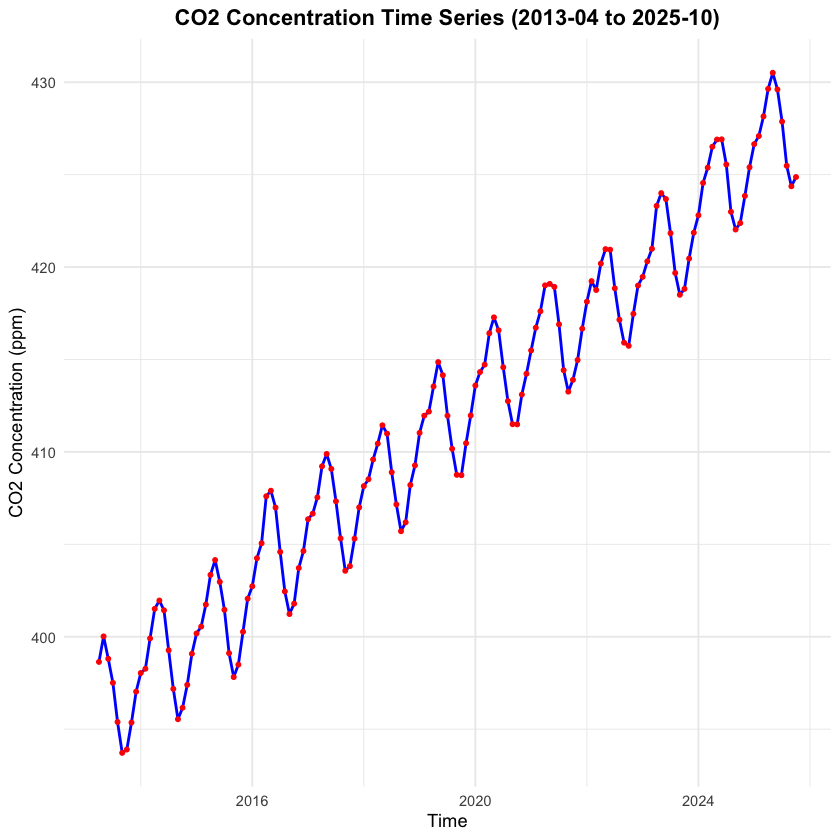

In [ ]:
# ============================================================
# Load Libraries
# ============================================================
library(forecast)   # For ARIMA modeling and forecasting
library(httr)       # For HTTP requests
library(readr)      # For reading data
library(ggplot2)    # For visualization

# ============================================================
# Download CO2 Data from NOAA Global Monitoring Laboratory
# ============================================================
cat("Downloading CO2 concentration data from NOAA GML...\n")

# URL for Mauna Loa CO2 data (monthly averages)
co2_url <- "https://gml.noaa.gov/webdata/ccgg/trends/co2/co2_mm_mlo.txt"

tryCatch({
  # Download the file
  response <- GET(co2_url)
  co2_text <- content(response, "text")

  # Read the data (skip header lines)
  co2_data <- read_table(co2_text, skip = 50, col_names = FALSE)

  # Extract relevant columns
  years <- co2_data$X1
  months <- co2_data$X2
  co2_values <- co2_data$X4  # Monthly average CO2 concentration

  # Create time series object (monthly frequency = 12)
  ts_co2 <- ts(co2_values, start = c(years[1], months[1]), frequency = 12)

  cat(sprintf("Downloaded CO2 data from %d-%d to %d-%d\n",
              years[1], months[1], tail(years, 1), tail(months, 1)))

  # ============================================================
  # Extract Fixed Time Period: 2013-04 to 2025-10 (151 months)
  # ============================================================
  start_year <- 2013
  start_month <- 4
  end_year <- 2025
  end_month <- 10

  # Extract data for the fixed time period
  subset_data <- window(ts_co2, 
                        start = c(start_year, start_month), 
                        end = c(end_year, end_month))

  total_extracted <- length(subset_data)

  cat(sprintf("\n*** EXTRACTED %d DATA POINTS ***\n", total_extracted))
  cat(sprintf("Time period: %d-%02d to %d-%02d\n", 
              start_year, start_month, end_year, end_month))

  # ============================================================
  # Plot: Time Series Visualization
  # ============================================================
  ts_df <- data.frame(
    Time = time(subset_data),
    CO2 = as.numeric(subset_data)
  )

  p <- ggplot(ts_df, aes(x = Time, y = CO2)) +
    geom_line(color = "blue", linewidth = 0.8) +
    geom_point(color = "red", size = 1) +
    labs(
      title = "CO2 Concentration Time Series (2013-04 to 2025-10)",
      subtitle = "Mauna Loa Observatory - Monthly Averages",
      x = "Year",
      y = "CO2 Concentration (ppm)"
    ) +
    theme_minimal() +
    theme(
      plot.title = element_text(hjust = 0.5, face = "bold"),
      plot.subtitle = element_text(hjust = 0.5)
    )

  print(p)

}, error = function(e) {
  cat("Download failed: ", e$message, "\n")
})

## 2. Data Acquisition and Visualization

Download CO2 concentration data from NOAA and create the initial time series plot.

In [ ]:
# ============================================================
# Split Data: Training (146 months) + Validation (5 months)
# ============================================================
model_data <- head(subset_data, 146)      # Training data
validation_data <- tail(subset_data, 5)   # Hold-out validation data

cat("*** DATA SPLIT ***\n")
cat(sprintf("Training dataset:   %d months (for model building)\n", length(model_data)))
cat(sprintf("Validation dataset: %d months (for forecast evaluation)\n", length(validation_data)))


*** DATA SPLIT ***
Model dataset: 146 months
Validation dataset: 5 months


## 3. Data Splitting

Split the data into **training set** (146 months) for model building and **validation set** (5 months) for forecast evaluation.

In [ ]:
# ============================================================
# Mean and Variance Stability Analysis (First Differenced Data)
# ============================================================
cat("*** MEAN AND VARIANCE STABILITY ANALYSIS ***\n\n")

# Apply first differencing to remove trend
diff_data <- diff(model_data)

# Split into 4 equal segments to test stability over time
n_segments <- 4
segment_length <- floor(length(diff_data) / n_segments)

means <- numeric(n_segments)
variances <- numeric(n_segments)

cat("Segment  Time Period        Mean      Variance\n")
cat("----------------------------------------------\n")

for(i in 1:n_segments) {
  start_idx <- (i-1) * segment_length + 1
  end_idx <- i * segment_length
  segment <- diff_data[start_idx:end_idx]
  
  means[i] <- mean(segment, na.rm = TRUE)
  variances[i] <- var(segment, na.rm = TRUE)
  
  cat(sprintf("%d        %3d - %3d        %7.4f    %7.4f\n",
              i, start_idx, end_idx, means[i], variances[i]))
}

# ============================================================
# Statistical Tests for Stability
# ============================================================
cat("\n*** STATISTICAL TESTS ***\n")

# Test 1: ANOVA for constant mean across segments
segment_factor <- rep(1:n_segments, each = segment_length)[1:length(diff_data)]
mean_test <- summary(aov(diff_data ~ factor(segment_factor[1:length(diff_data)])))
p_mean <- mean_test[[1]]$`Pr(>F)`[1]

cat(sprintf("\n1. ANOVA test for constant mean:\n"))
cat(sprintf("   p-value = %.4f\n", p_mean))
if(p_mean > 0.05) {
  cat("   ✓ Mean is CONSTANT across time (p > 0.05)\n")
} else {
  cat("   ✗ Mean varies across time (p ≤ 0.05)\n")
}

# Test 2: Bartlett's test for constant variance
bartlett_test <- bartlett.test(list(
  diff_data[1:segment_length],
  diff_data[(segment_length+1):(2*segment_length)],
  diff_data[(2*segment_length+1):(3*segment_length)],
  diff_data[(3*segment_length+1):length(diff_data)]
))

cat(sprintf("\n2. Bartlett's test for constant variance:\n"))
cat(sprintf("   p-value = %.4f\n", bartlett_test$p.value))
if(bartlett_test$p.value > 0.05) {
  cat("   ✓ Variance is CONSTANT across time (p > 0.05)\n")
} else {
  cat("   ✗ Variance varies across time (p ≤ 0.05)\n")
}

*** MEAN AND VARIANCE STABILITY ANALYSIS AFTER FIRST DIFFERENCING ***
Segment  Time Period        Mean      Variance
---------------------------------------------
1        1-36           0.2489     2.0537
2        37-72           0.1650     1.8578
3        73-108           0.1847     1.8301
4        109-144           0.2625     1.6857

*** STATISTICAL TESTS FOR STABILITY ***
ANOVA p-value for constant mean: 0.9876
✓ Mean is constant across time segments (p > 0.05)
Bartlett's test p-value for constant variance: 0.9352
✓ Variance is constant across time segments (p > 0.05)


## 4. Stationarity Analysis

### 4.1 Mean and Variance Stability Test

Test whether the differenced series has constant mean and variance across time segments using ANOVA and Bartlett's test.

In [ ]:
# ============================================================
# Augmented Dickey-Fuller (ADF) Tests for Stationarity
# ============================================================
library(tseries)

cat("*** AUGMENTED DICKEY-FULLER TESTS ***\n")
cat("H0: Series has a unit root (non-stationary)\n")
cat("H1: Series is stationary\n\n")

# Calculate optimal lag length using Schwert (1989) formula
optimal_lags <- floor(12 * (length(model_data)/100)^(1/4))
cat(sprintf("Optimal lag length (Schwert formula): %d\n\n", optimal_lags))

# Test 1: Original data
cat("1. ORIGINAL DATA:\n")
adf_original <- adf.test(model_data, k = optimal_lags)
cat(sprintf("   ADF p-value: %.2e\n", adf_original$p.value))
cat(ifelse(adf_original$p.value < 0.05, 
           "   ✓ Stationary (reject H0)\n", 
           "   ✗ Non-stationary (fail to reject H0)\n"))

# Test 2: Log-transformed data
cat("\n2. LOG-TRANSFORMED DATA:\n")
log_data <- log(model_data)
adf_log <- adf.test(log_data, k = optimal_lags)
cat(sprintf("   ADF p-value: %.2e\n", adf_log$p.value))
cat(ifelse(adf_log$p.value < 0.05, 
           "   ✓ Stationary (reject H0)\n", 
           "   ✗ Non-stationary (fail to reject H0)\n"))

# Test 3: Double log-transformed data
cat("\n3. DOUBLE LOG-TRANSFORMED DATA:\n")
log2_data <- log(log_data)
adf_log2 <- adf.test(log2_data, k = optimal_lags)
cat(sprintf("   ADF p-value: %.2e\n", adf_log2$p.value))
cat(ifelse(adf_log2$p.value < 0.05, 
           "   ✓ Stationary (reject H0)\n", 
           "   ✗ Non-stationary (fail to reject H0)\n"))

cat("\n*** CONCLUSION: Data requires differencing to achieve stationarity ***")

*** AUGMENTED DICKEY-FULLER TESTS ***
Optimal lag length: 13

1. ORIGINAL DATA:
ADF p-value: 7.15e-01
✗ Non-stationary (p >= 0.05)

2. LOG TRANSFORMED DATA:
ADF p-value: 6.19e-01
✗ Non-stationary (p >= 0.05)

3. DOUBLE LOG TRANSFORMED DATA:
ADF p-value: 6.08e-01
✗ Non-stationary (p >= 0.05)


### 4.2 Augmented Dickey-Fuller (ADF) Test

Test for unit root (non-stationarity) using the ADF test on original, log-transformed, and double-log transformed data.

Don't know how to automatically pick scale for object of type <ts>. Defaulting
to continuous.
`geom_smooth()` using formula = 'y ~ x'



*** LOG-TRANSFORMED DATA TREND ***
Trend slope: 6.14e-03 per year
R-squared: 0.9369
P-value: 2.65e-88


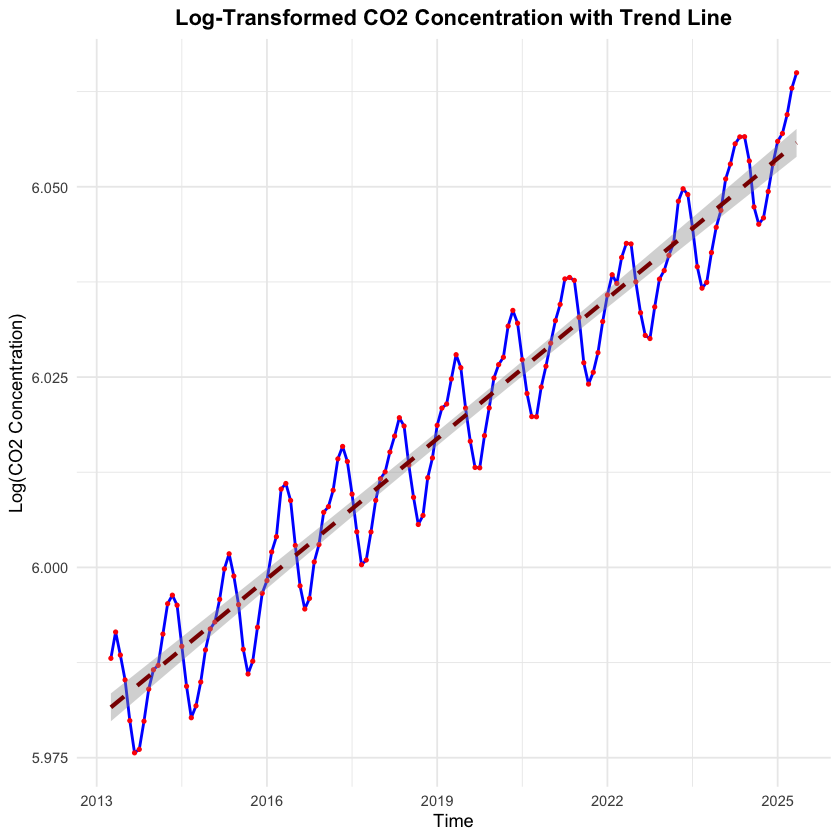

In [ ]:
# ============================================================
# Visualize Log-Transformed Data with Trend Line
# ============================================================
log_model_data <- log(model_data)

log_df <- data.frame(
  Time = time(log_model_data),
  Log_CO2 = as.numeric(log_model_data)
)

p <- ggplot(log_df, aes(x = Time, y = Log_CO2)) +
  geom_line(color = "blue", linewidth = 0.8) +
  geom_point(color = "red", size = 0.8) +
  geom_smooth(method = "lm", se = TRUE, color = "darkred", 
              linetype = "dashed", linewidth = 1.2) +
  labs(
    title = "Log-Transformed CO2 Concentration with Trend Line",
    x = "Year",
    y = "Log(CO2 Concentration)"
  ) +
  theme_minimal() +
  theme(plot.title = element_text(hjust = 0.5, face = "bold"))

print(p)

# Calculate and display trend statistics
trend_model <- lm(Log_CO2 ~ Time, data = log_df)
cat("\n*** TREND ANALYSIS ***\n")
cat(sprintf("Trend slope:  %.6f per year\n", coef(trend_model)[2]))
cat(sprintf("R-squared:    %.4f\n", summary(trend_model)$r.squared))
cat(sprintf("p-value:      %.2e\n", summary(trend_model)$coefficients[2,4]))

### 4.3 Log-Transformed Data Visualization

Visualize the log-transformed data with a linear trend line to observe the overall pattern.

Don't know how to automatically pick scale for object of type <ts>. Defaulting
to continuous.
`geom_smooth()` using formula = 'y ~ x'



*** FIRST DIFFERENCED LOG DATA TREND ***
Trend slope: 2.37e-02 per year
R-squared: 0.0038
P-value: 4.62e-01


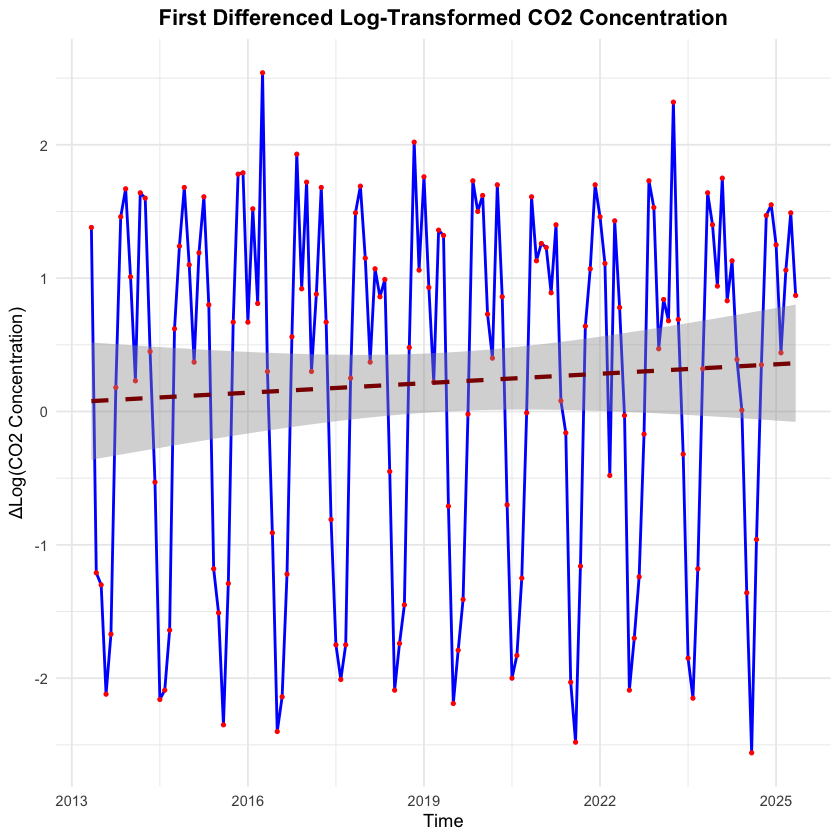

In [ ]:
# ============================================================
# First Differencing to Achieve Stationarity
# ============================================================
diff_data <- diff(model_data)

diff_df <- data.frame(
  Time = time(diff_data),
  Diff_CO2 = as.numeric(diff_data)
)

p <- ggplot(diff_df, aes(x = Time, y = Diff_CO2)) +
  geom_line(color = "blue", linewidth = 0.8) +
  geom_point(color = "red", size = 0.8) +
  geom_smooth(method = "lm", se = TRUE, color = "darkred", 
              linetype = "dashed", linewidth = 1.2) +
  geom_hline(yintercept = 0, color = "black", linetype = "solid") +
  labs(
    title = "First Differenced CO2 Concentration",
    subtitle = "Trend removed - checking for stationarity",
    x = "Year",
    y = "ΔCO2 (ppm)"
  ) +
  theme_minimal() +
  theme(
    plot.title = element_text(hjust = 0.5, face = "bold"),
    plot.subtitle = element_text(hjust = 0.5)
  )

print(p)

# Trend analysis of differenced data
trend_model <- lm(Diff_CO2 ~ Time, data = diff_df)
cat("\n*** DIFFERENCED DATA TREND ***\n")
cat(sprintf("Trend slope:  %.6f per year\n", coef(trend_model)[2]))
cat(sprintf("R-squared:    %.4f (should be near 0)\n", summary(trend_model)$r.squared))
cat(sprintf("p-value:      %.2e\n", summary(trend_model)$coefficients[2,4]))

### 4.4 First Differenced Data

Apply first differencing to remove the trend component and visualize the result.

In [ ]:
# ============================================================
# Ljung-Box Test for White Noise
# ============================================================
# H0: Data is white noise (no autocorrelation)
# H1: Data has significant autocorrelation

n <- length(diff_data)
k <- min(10, floor(n/5))  # Recommended lag selection

cat("*** LJUNG-BOX TEST FOR WHITE NOISE ***\n")
cat(sprintf("Sample size: %d\n", n))
cat(sprintf("Lags tested (k): %d\n\n", k))

ljung_test <- Box.test(diff_data, lag = k, type = "Ljung-Box")

cat(sprintf("Test statistic (Q): %.4f\n", ljung_test$statistic))
cat(sprintf("p-value: %.2e\n\n", ljung_test$p.value))

if(ljung_test$p.value > 0.05) {
  cat("✓ Result: Data IS white noise (p > 0.05)\n")
  cat("  No significant autocorrelation detected.\n")
} else {
  cat("✗ Result: Data is NOT white noise (p ≤ 0.05)\n")
  cat("  Significant autocorrelation exists - ARIMA modeling needed.\n")
}

*** LJUNG-BOX TEST FOR WHITE NOISE ***
Sample size: 145
Lags used (k): 10

Ljung-Box Test Results:
Test statistic: 235.4275
P-value: 0.00e+00
✗ Data is NOT white noise (p <= 0.05)


### 4.5 Ljung-Box Test for White Noise

Test whether the differenced series is white noise (no autocorrelation).

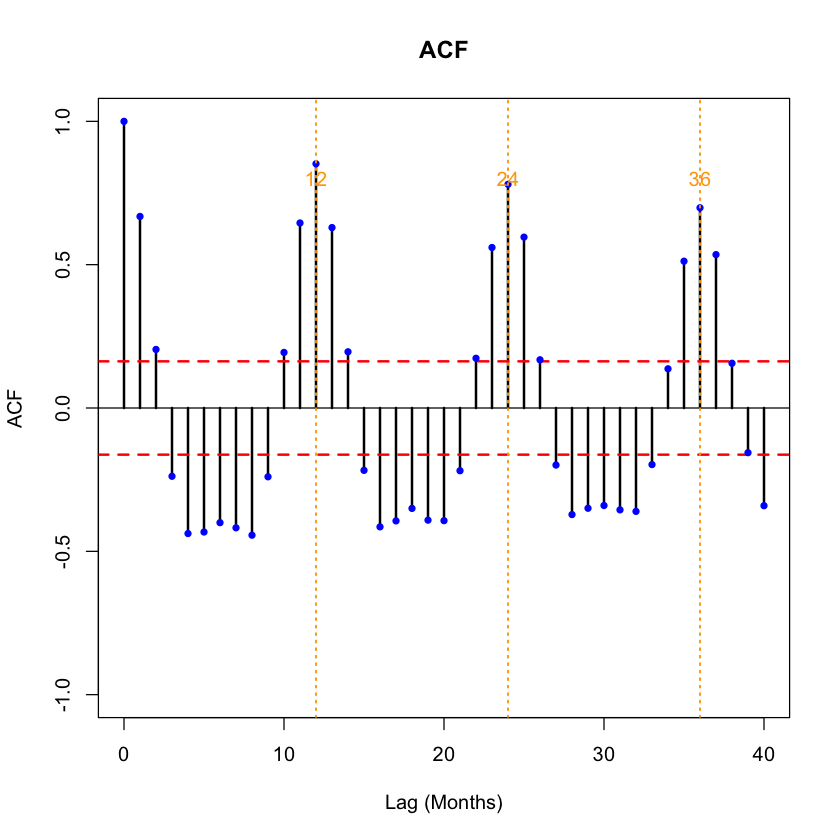

*** HOW TO OBSERVE SEASONALITY ***
Look for significant spikes (outside red lines) at:
- Lag 12 (1 year seasonality)
- Lag 24 (2 year seasonality)
- Lag 36 (3 year seasonality)

SEASONAL PATTERNS:
- ACF: Gradual decay at seasonal lags = Seasonal AR component
- PACF: Single spike at seasonal lag = Seasonal MA component
- Multiple significant spikes = Mixed seasonal ARMA


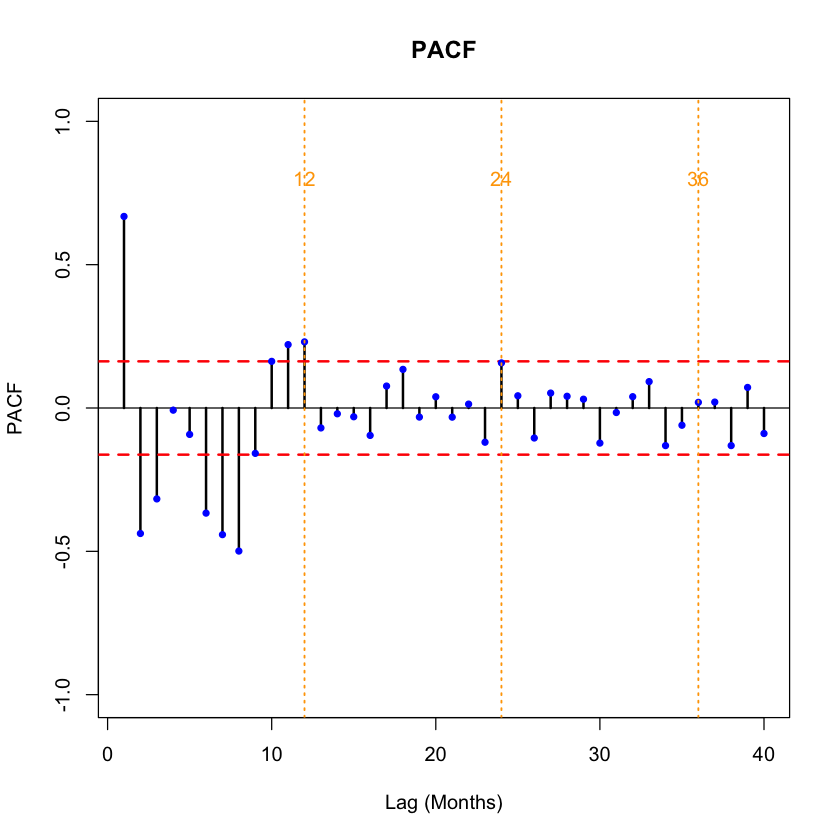

In [ ]:
# ============================================================
# ACF and PACF Analysis for Model Identification
# ============================================================
acf_values <- acf(diff_data, lag.max = 40, plot = FALSE)
pacf_values <- pacf(diff_data, lag.max = 40, plot = FALSE)

# Set up 2-panel plot
par(mfrow = c(2, 1))

# ACF Plot
plot(0:40, c(1, acf_values$acf[2:41]), type = "h",
     main = "Autocorrelation Function (ACF)",
     xlab = "Lag (Months)", ylab = "ACF",
     ylim = c(-1, 1), lwd = 2)
abline(h = c(-1, 1) * 1.96/sqrt(length(diff_data)), 
       col = "red", lty = 2, lwd = 2)
abline(h = 0, col = "black")
points(0:40, c(1, acf_values$acf[2:41]), pch = 20, col = "blue")
# Mark seasonal lags (12, 24, 36)
abline(v = c(12, 24, 36), col = "orange", lty = 3, lwd = 1.5)
text(x = c(12, 24, 36), y = 0.9, labels = c("12", "24", "36"), col = "orange")

# PACF Plot
plot(1:40, pacf_values$acf, type = "h",
     main = "Partial Autocorrelation Function (PACF)",
     xlab = "Lag (Months)", ylab = "PACF",
     ylim = c(-1, 1), lwd = 2)
abline(h = c(-1, 1) * 1.96/sqrt(length(diff_data)), 
       col = "red", lty = 2, lwd = 2)
abline(h = 0, col = "black")
points(1:40, pacf_values$acf, pch = 20, col = "blue")
# Mark seasonal lags
abline(v = c(12, 24, 36), col = "orange", lty = 3, lwd = 1.5)
text(x = c(12, 24, 36), y = 0.9, labels = c("12", "24", "36"), col = "orange")

par(mfrow = c(1, 1))

# Interpretation guide
cat("\n*** INTERPRETING ACF/PACF FOR SEASONALITY ***\n")
cat("━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━\n")
cat("Look for significant spikes (beyond red lines) at:\n")
cat("• Lag 12: 1-year seasonality\n")
cat("• Lag 24: 2-year seasonality\n")
cat("• Lag 36: 3-year seasonality\n\n")
cat("SEASONAL PATTERN INTERPRETATION:\n")
cat("• ACF: Slow decay at seasonal lags → Seasonal AR component\n")
cat("• PACF: Single spike at lag 12 → Seasonal MA component\n")
cat("• Both significant → Mixed seasonal ARMA\n")

## 5. Model Identification

### 5.1 ACF and PACF Analysis

Use Autocorrelation Function (ACF) and Partial Autocorrelation Function (PACF) plots to identify potential ARIMA orders and seasonal patterns.

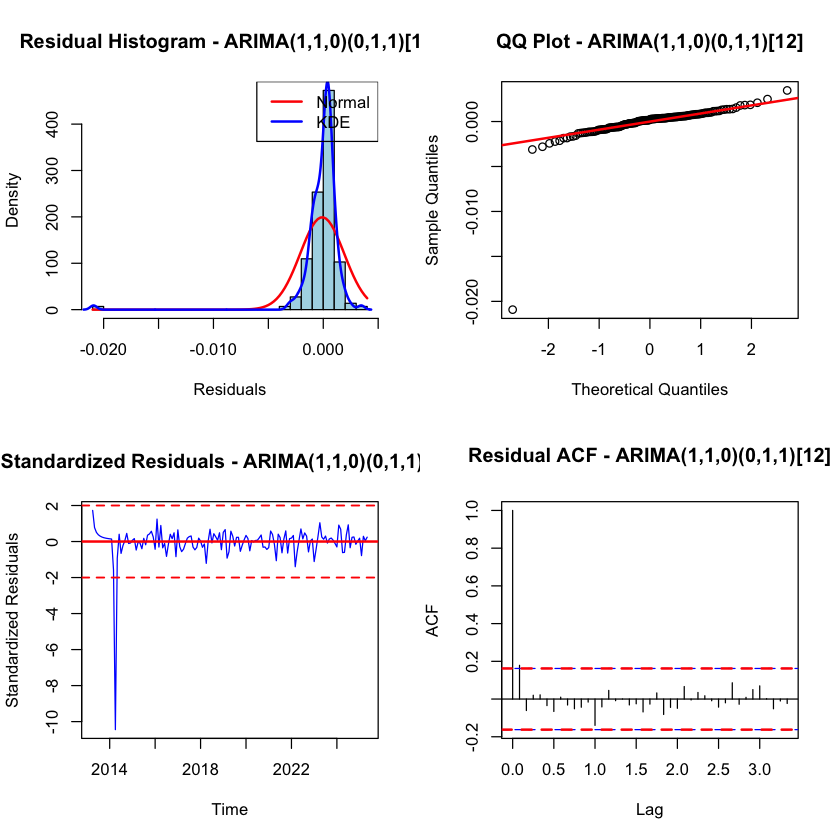

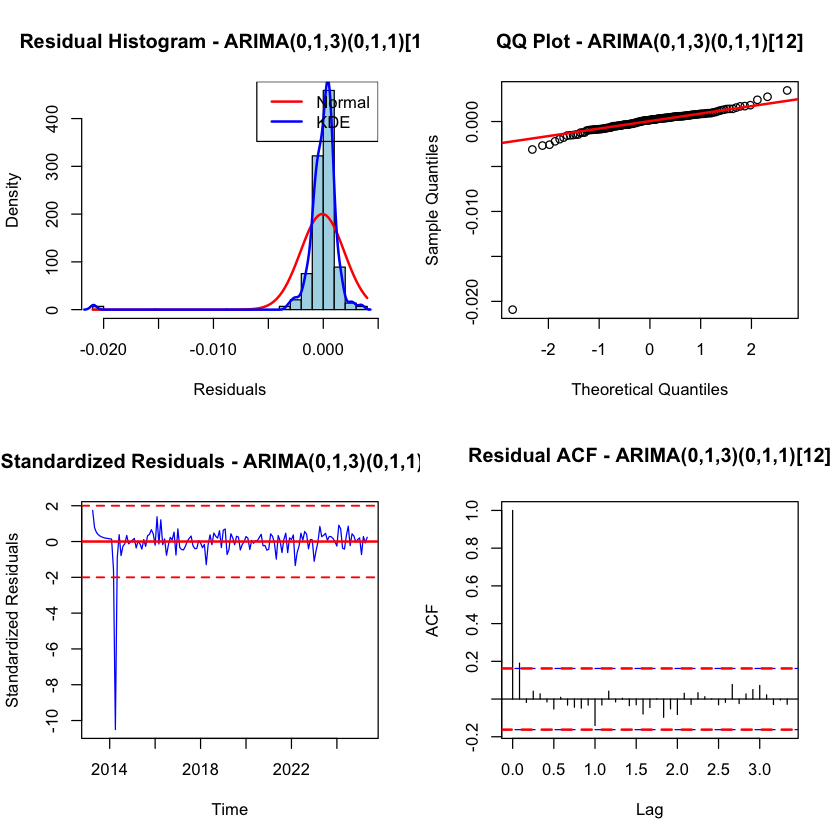

In [ ]:
# ============================================================
# Fit Candidate SARIMA Models
# ============================================================
# Model 1: ARIMA(1,1,0)(0,1,1)[12] - AR(1) with seasonal MA
# Model 2: ARIMA(0,1,3)(0,1,1)[12] - MA(3) with seasonal MA

model1 <- Arima(log_model_data, order = c(1,1,0), seasonal = c(0,1,1))
model2 <- Arima(log_model_data, order = c(0,1,3), seasonal = c(0,1,1))

# ============================================================
# Function: Residual Diagnostic Plots
# ============================================================
plot_residual_diagnostics <- function(model, model_name) {
  residuals <- residuals(model)
  standardized_residuals <- residuals / sd(residuals)
  
  par(mfrow = c(2, 2))
  
  # 1. Histogram with normal curve
  hist(residuals, prob = TRUE, 
       main = paste("Residual Histogram -", model_name),
       xlab = "Residuals", col = "lightblue", breaks = 20)
  curve(dnorm(x, mean = mean(residuals), sd = sd(residuals)),
        add = TRUE, col = "red", lwd = 2)
  lines(density(residuals), col = "blue", lwd = 2)
  legend("topright", legend = c("Normal", "KDE"), 
         col = c("red", "blue"), lwd = 2, cex = 0.8)
  
  # 2. Q-Q Plot
  qqnorm(residuals, main = paste("Q-Q Plot -", model_name))
  qqline(residuals, col = "red", lwd = 2)
  
  # 3. Standardized Residuals Time Plot
  plot(standardized_residuals, type = "l", 
       main = paste("Standardized Residuals -", model_name),
       ylab = "Standardized Residuals", xlab = "Time", col = "blue")
  abline(h = 0, col = "red", lwd = 2)
  abline(h = c(-2, 2), col = "red", lty = 2, lwd = 1.5)
  
  # 4. Residual ACF
  acf(residuals, main = paste("Residual ACF -", model_name), lag.max = 40)
  abline(h = c(-1, 1) * 1.96/sqrt(length(residuals)), 
         col = "red", lty = 2, lwd = 2)
  
  par(mfrow = c(1, 1))
}

# Generate diagnostic plots for both models
plot_residual_diagnostics(model1, "ARIMA(1,1,0)(0,1,1)[12]")
plot_residual_diagnostics(model2, "ARIMA(0,1,3)(0,1,1)[12]")

## 6. Initial Model Fitting and Diagnostics

### 6.1 Candidate Models Comparison

Fit two candidate SARIMA models based on ACF/PACF analysis and compare their residual diagnostics.

In [ ]:
# ============================================================
# Shapiro-Wilk Normality Tests
# ============================================================
# H0: Residuals are normally distributed
# H1: Residuals are not normally distributed

cat("*** SHAPIRO-WILK NORMALITY TESTS ***\n")
cat("━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━\n\n")

# Model 1
residuals1 <- residuals(model1)
shapiro1 <- shapiro.test(residuals1)
cat("Model 1 - ARIMA(1,1,0)(0,1,1)[12]:\n")
cat(sprintf("  Shapiro-Wilk p-value: %.4f\n", shapiro1$p.value))
cat(ifelse(shapiro1$p.value > 0.05, 
           "  ✓ Residuals are NORMAL (p > 0.05)\n\n", 
           "  ✗ Residuals are NOT normal (p ≤ 0.05)\n\n"))

# Model 2
residuals2 <- residuals(model2)
shapiro2 <- shapiro.test(residuals2)
cat("Model 2 - ARIMA(0,1,3)(0,1,1)[12]:\n")
cat(sprintf("  Shapiro-Wilk p-value: %.4f\n", shapiro2$p.value))
cat(ifelse(shapiro2$p.value > 0.05, 
           "  ✓ Residuals are NORMAL (p > 0.05)\n", 
           "  ✗ Residuals are NOT normal (p ≤ 0.05)\n"))

*** SHAPIRO-WILK NORMALITY TESTS ***

Model 1 - ARIMA(1,1,0)(0,1,1)[12]:
Shapiro-Wilk p-value: 0.0000
✗ Residuals are NOT normal (p <= 0.05)

Model 2 - ARIMA(0,1,3)(0,1,1)[12]:
Shapiro-Wilk p-value: 0.0000
✗ Residuals are NOT normal (p <= 0.05)


### 6.2 Shapiro-Wilk Normality Test

Test whether the residuals follow a normal distribution (required for valid inference).

In [ ]:
# ============================================================
# Ljung-Box Tests for Residual Autocorrelation (Lags 1-15)
# ============================================================
cat("*** LJUNG-BOX TESTS FOR RESIDUALS ***\n")
cat("H0: Residuals are white noise (no autocorrelation)\n\n")

# Model 1
cat("Model 1 - ARIMA(1,1,0)(0,1,1)[12]:\n")
cat("Lag    p-value    White Noise?\n")
cat("─────────────────────────────────\n")
for(k in 1:15) {
  lb_test <- Box.test(residuals1, lag = k, type = "Ljung-Box")
  status <- ifelse(lb_test$p.value > 0.05, "✓", "✗")
  cat(sprintf("%2d     %.4f         %s\n", k, lb_test$p.value, status))
}

# Model 2
cat("\nModel 2 - ARIMA(0,1,3)(0,1,1)[12]:\n")
cat("Lag    p-value    White Noise?\n")
cat("─────────────────────────────────\n")
for(k in 1:15) {
  lb_test <- Box.test(residuals2, lag = k, type = "Ljung-Box")
  status <- ifelse(lb_test$p.value > 0.05, "✓", "✗")
  cat(sprintf("%2d     %.4f         %s\n", k, lb_test$p.value, status))
}

*** LJUNG-BOX TESTS FOR LAGS 1-15 ***

Model 1 - ARIMA(1,1,0)(0,1,1)[12]:
Lag  P-value    Autocorrelation?
-----------------------------
 1   0.0290     ✗
 2   0.0700     ✓
 3   0.1460     ✓
 4   0.2438     ✓
 5   0.3430     ✓
 6   0.3900     ✓
 7   0.5030     ✓
 8   0.5943     ✓
 9   0.6483     ✓
10   0.7075     ✓
11   0.7802     ✓
12   0.5840     ✓
13   0.6405     ✓
14   0.6870     ✓
15   0.7526     ✓

Model 2 - ARIMA(0,1,3)(0,1,1)[12]:
Lag  P-value    Autocorrelation?
-----------------------------
 1   0.0201     ✗
 2   0.0655     ✓
 3   0.1265     ✓
 4   0.2124     ✓
 5   0.3198     ✓
 6   0.3907     ✓
 7   0.5039     ✓
 8   0.5946     ✓
 9   0.6611     ✓
10   0.7123     ✓
11   0.7739     ✓
12   0.5735     ✓
13   0.6404     ✓
14   0.6914     ✓
15   0.7548     ✓


### 6.3 Ljung-Box Tests for Residual Autocorrelation

Test whether residuals are white noise (no remaining autocorrelation) at multiple lags.

In [ ]:
# ============================================================
# Overparameterization Testing
# ============================================================
# Test if adding extra parameters significantly improves the model

cat("*** OVERPARAMETERIZATION TESTING ***\n")
cat("Testing if additional parameters are significant...\n")
cat("━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━\n")

# Helper function to safely extract p-values
get_p_value <- function(model, param) {
  tryCatch({
    coef_summary <- summary(model)
    if (param %in% rownames(coef_summary$coef)) {
      p_val <- coef_summary$coef[param, "Pr(>|z|)"]
      return(ifelse(is.numeric(p_val) && !is.na(p_val), p_val, NA))
    }
    return(NA)
  }, error = function(e) NA)
}

# === MODEL 1 EXTENSIONS ===
cat("\n=== MODEL 1: ARIMA(1,1,0)(0,1,1)[12] ===\n")

# Add AR2
model1_ar2 <- Arima(model_data, order = c(2,1,0), seasonal = c(0,1,1), method = "ML")
cat(sprintf("\nARIMA(2,1,0)(0,1,1)[12]:\n"))
cat(sprintf("  AIC: %.2f (Original: %.2f)\n", AIC(model1_ar2), AIC(model1)))
cat(sprintf("  AR2 p-value: %.4f %s\n", 
            get_p_value(model1_ar2, "ar2"),
            ifelse(get_p_value(model1_ar2, "ar2") < 0.05, "(significant)", "(not significant)")))

# Add MA1
model1_ma1 <- Arima(model_data, order = c(1,1,1), seasonal = c(0,1,1), method = "ML")
cat(sprintf("\nARIMA(1,1,1)(0,1,1)[12]:\n"))
cat(sprintf("  AIC: %.2f (Original: %.2f)\n", AIC(model1_ma1), AIC(model1)))
cat(sprintf("  MA1 p-value: %.4f %s\n", 
            get_p_value(model1_ma1, "ma1"),
            ifelse(get_p_value(model1_ma1, "ma1") < 0.05, "(significant)", "(not significant)")))

# Add SAR1
model1_sar1 <- Arima(model_data, order = c(1,1,0), seasonal = c(1,1,1), method = "ML")
cat(sprintf("\nARIMA(1,1,0)(1,1,1)[12]:\n"))
cat(sprintf("  AIC: %.2f (Original: %.2f)\n", AIC(model1_sar1), AIC(model1)))
cat(sprintf("  SAR1 p-value: %.4f %s\n", 
            get_p_value(model1_sar1, "sar1"),
            ifelse(get_p_value(model1_sar1, "sar1") < 0.05, "(significant)", "(not significant)")))

# === MODEL 2 EXTENSIONS ===
cat("\n=== MODEL 2: ARIMA(0,1,3)(0,1,1)[12] ===\n")

# Add AR1
model2_ar1 <- Arima(model_data, order = c(1,1,3), seasonal = c(0,1,1), method = "ML")
cat(sprintf("\nARIMA(1,1,3)(0,1,1)[12]:\n"))
cat(sprintf("  AIC: %.2f (Original: %.2f)\n", AIC(model2_ar1), AIC(model2)))
cat(sprintf("  AR1 p-value: %.4f %s\n", 
            get_p_value(model2_ar1, "ar1"),
            ifelse(get_p_value(model2_ar1, "ar1") < 0.05, "(significant)", "(not significant)")))

# Add MA4
model2_ma4 <- Arima(model_data, order = c(0,1,4), seasonal = c(0,1,1), method = "ML")
cat(sprintf("\nARIMA(0,1,4)(0,1,1)[12]:\n"))
cat(sprintf("  AIC: %.2f (Original: %.2f)\n", AIC(model2_ma4), AIC(model2)))
cat(sprintf("  MA4 p-value: %.4f %s\n", 
            get_p_value(model2_ma4, "ma4"),
            ifelse(get_p_value(model2_ma4, "ma4") < 0.05, "(significant)", "(not significant)")))

cat("\n*** MODEL SELECTION CRITERIA ***\n")
cat("Choose model with: Lowest AIC, significant parameters,\n")
cat("normal residuals, and no autocorrelation in residuals.\n")

*** OVERPARAMETERIZATION TESTING ***

=== MODEL 1: ARIMA(1,1,0)(0,1,1)[12] ===

ARIMA(2,1,0)(0,1,1)[12]:
AIC: 135.48 (Original: -1460.45)
AR2 coefficient: -0.1967 (p-value: NA)
Shapiro p-value: 0.0089

ARIMA(1,1,1)(0,1,1)[12]:
AIC: 131.92 (Original: -1460.45)
MA1 coefficient: -0.6380 (p-value: NA)
Shapiro p-value: 0.0078

ARIMA(1,1,0)(1,1,1)[12]:
AIC: 139.34 (Original: -1460.45)
SAR1 coefficient: -0.1558 (p-value: NA)
Shapiro p-value: 0.0116

=== MODEL 2: ARIMA(0,1,3)(0,1,1)[12] ===

ARIMA(1,1,3)(0,1,1)[12]:
AIC: 135.63 (Original: -1464.36)
AR1 coefficient: -0.5049 (p-value: NA)
Shapiro p-value: 0.0076

ARIMA(0,1,4)(0,1,1)[12]:
AIC: 135.37 (Original: -1464.36)
MA4 coefficient: 0.0733 (p-value: NA)
Shapiro p-value: 0.0113

ARIMA(0,1,3)(1,1,1)[12]:
AIC: 135.47 (Original: -1464.36)
SAR1 coefficient: -0.0837 (p-value: NA)
Shapiro p-value: 0.0065

*** FINAL RECOMMENDATION ***
Choose model with:
- Lowest AIC
- Significant new parameters (p < 0.05)
- Normal residuals (Shapiro p > 0.05)
- No r

### 6.4 Overparameterization Testing

Test if adding additional parameters improves model fit (to avoid overfitting).

In [ ]:
# ============================================================
# Exhaustive SARIMA Model Search
# ============================================================
# Search all SARIMA(p,d,q)(P,D,Q)[12] combinations
# Filter: Models must pass Shapiro-Wilk normality test (p > 0.05)

cat("*** EXHAUSTIVE SARIMA MODEL SEARCH ***\n")
cat("Searching for models with normal residuals...\n")
cat("━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━\n\n")

# Define search space
p_values <- 0:3    # AR order
q_values <- 0:3    # MA order
P_values <- 0:3    # Seasonal AR order
Q_values <- 0:3    # Seasonal MA order
d_values <- 0:1    # Regular differencing
D_values <- 1      # Seasonal differencing (fixed at 1)

valid_models <- list()
model_count <- 0
total_combinations <- length(p_values) * length(q_values) * length(P_values) * 
                      length(Q_values) * length(d_values) * length(D_values)

cat(sprintf("Total combinations to test: %d\n\n", total_combinations))

# Search loop
for(p in p_values) {
  for(d in d_values) {
    for(q in q_values) {
      for(P in P_values) {
        for(D in D_values) {
          for(Q in Q_values) {
            
            # Skip invalid combinations
            if(p + q + P + Q == 0) next  # Need at least one parameter
            if(p + q + P + Q > 6) next   # Limit complexity
            
            model_count <- model_count + 1
            
            tryCatch({
              model <- Arima(model_data, order = c(p, d, q),
                            seasonal = c(P, D, Q), method = "ML")
              
              shapiro_test <- shapiro.test(residuals(model))
              
              # Store if passes normality test
              if(shapiro_test$p.value > 0.05) {
                model_name <- sprintf("ARIMA(%d,%d,%d)(%d,%d,%d)[12]", 
                                     p, d, q, P, D, Q)
                valid_models[[model_name]] <- list(
                  model = model,
                  aic = AIC(model),
                  shapiro_p = shapiro_test$p.value,
                  formula = model_name
                )
                cat(sprintf("✓ %s: AIC=%.2f, Shapiro p=%.4f\n",
                           model_name, AIC(model), shapiro_test$p.value))
              }
            }, error = function(e) { })
          }
        }
      }
    }
  }
}

# Sort and display results
cat(sprintf("\n*** FOUND %d MODELS PASSING SHAPIRO-WILK TEST ***\n\n", 
            length(valid_models)))

if(length(valid_models) > 0) {
  # Sort by AIC
  aic_values <- sapply(valid_models, function(x) x$aic)
  valid_models <- valid_models[order(aic_values)]
  
  cat("TOP 10 MODELS (Sorted by AIC):\n")
  cat("Model                         AIC      Shapiro p\n")
  cat("─────────────────────────────────────────────────\n")
  
  for(i in 1:min(10, length(valid_models))) {
    model_name <- names(valid_models)[i]
    model_info <- valid_models[[i]]
    cat(sprintf("%-28s %8.2f    %.4f\n",
                model_name, model_info$aic, model_info$shapiro_p))
  }
  
  # Best model summary
  best_name <- names(valid_models)[1]
  best_info <- valid_models[[1]]
  cat(sprintf("\n*** BEST MODEL: %s ***\n", best_name))
  cat(sprintf("AIC: %.2f | Shapiro p-value: %.4f\n", best_info$aic, best_info$shapiro_p))
}

cat(sprintf("\nSearched %d model combinations\n", model_count))

*** STEPWISE SEARCH FOR SARIMA MODELS PASSING SHAPIRO-WILK TEST ***
Searching through 512 possible models...

✓ ARIMA(0,0,0)(0,1,1)[12]: AIC=543.19, Shapiro p=0.6531
✓ ARIMA(0,0,0)(0,1,2)[12]: AIC=506.20, Shapiro p=0.1122
✓ ARIMA(0,0,0)(0,1,3)[12]: AIC=478.32, Shapiro p=0.8438
✓ ARIMA(0,0,0)(1,1,0)[12]: AIC=417.78, Shapiro p=0.6334
✓ ARIMA(0,0,0)(1,1,1)[12]: AIC=354.68, Shapiro p=0.2719
✓ ARIMA(0,0,0)(1,1,2)[12]: AIC=399.76, Shapiro p=0.1002
✓ ARIMA(0,0,0)(1,1,3)[12]: AIC=337.30, Shapiro p=0.0985
✓ ARIMA(0,0,0)(2,1,0)[12]: AIC=395.20, Shapiro p=0.0587
✓ ARIMA(0,0,0)(2,1,1)[12]: AIC=327.67, Shapiro p=0.5334
✓ ARIMA(0,0,0)(2,1,2)[12]: AIC=355.66, Shapiro p=0.2396
✓ ARIMA(0,0,0)(2,1,3)[12]: AIC=336.22, Shapiro p=0.2108
✓ ARIMA(0,0,0)(3,1,0)[12]: AIC=362.49, Shapiro p=0.3700
✓ ARIMA(0,0,0)(3,1,1)[12]: AIC=337.58, Shapiro p=0.1785
✓ ARIMA(0,0,0)(3,1,2)[12]: AIC=342.14, Shapiro p=0.4248
✓ ARIMA(0,0,0)(3,1,3)[12]: AIC=392.25, Shapiro p=0.1373
✓ ARIMA(0,0,1)(0,1,0)[12]: AIC=498.00, Shapiro p=0

## 7. Comprehensive Model Search

### 7.1 Exhaustive SARIMA Search

Systematically search through all SARIMA(p,d,q)(P,D,Q)[12] combinations and filter models that pass the Shapiro-Wilk normality test.

In [ ]:
# ============================================================
# Ljung-Box Tests for All Valid Models
# ============================================================
cat("*** LJUNG-BOX TESTS FOR ALL VALID MODELS ***\n")
cat("Testing residual autocorrelation at lags 1-15...\n")
cat("━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━\n")

if(length(valid_models) > 0) {
  
  # Find models with perfect white noise residuals
  perfect_models <- c()
  model_failures <- list()
  
  for(i in 1:length(valid_models)) {
    model_name <- names(valid_models)[i]
    model_info <- valid_models[[i]]
    residuals_model <- residuals(model_info$model)
    
    fail_count <- 0
    for(k in 1:15) {
      lb_test <- Box.test(residuals_model, lag = k, type = "Ljung-Box")
      if(lb_test$p.value <= 0.05) fail_count <- fail_count + 1
    }
    
    model_failures[[model_name]] <- fail_count
    
    if(fail_count == 0) {
      perfect_models <- c(perfect_models, model_name)
    }
  }
  
  # Display summary
  cat("\n*** MODEL SUMMARY ***\n")
  cat("Model                         AIC      Shapiro p   LB Failures\n")
  cat("───────────────────────────────────────────────────────────────\n")
  
  for(i in 1:min(15, length(valid_models))) {
    model_name <- names(valid_models)[i]
    model_info <- valid_models[[i]]
    failures <- model_failures[[model_name]]
    status <- ifelse(failures == 0, "✓", sprintf("%d", failures))
    cat(sprintf("%-28s %8.2f    %.4f      %s\n",
                model_name, model_info$aic, model_info$shapiro_p, status))
  }
  
  # Best models with perfect residuals
  cat("\n*** MODELS WITH PERFECT WHITE NOISE RESIDUALS ***\n")
  if(length(perfect_models) > 0) {
    for(model_name in perfect_models) {
      model_info <- valid_models[[model_name]]
      cat(sprintf("✓ %s: AIC=%.2f\n", model_name, model_info$aic))
    }
    
    # Find best perfect model
    best_aic <- Inf
    best_perfect <- NULL
    for(model_name in perfect_models) {
      if(valid_models[[model_name]]$aic < best_aic) {
        best_aic <- valid_models[[model_name]]$aic
        best_perfect <- model_name
      }
    }
    
    cat(sprintf("\n*** RECOMMENDED MODEL: %s ***\n", best_perfect))
    cat(sprintf("AIC: %.2f\n", best_aic))
    cat("✓ Normal residuals (Shapiro test passed)\n")
    cat("✓ White noise residuals (all Ljung-Box tests passed)\n")
    cat("✓ Lowest AIC among perfect models\n")
  } else {
    cat("⚠ No models have perfect white noise residuals.\n")
    cat("Consider the model with fewest Ljung-Box failures.\n")
  }
}

*** LJUNG-BOX TESTS FOR ALL VALID MODELS (Lags 1-15) ***



1. ARIMA(1,0,1)(0,1,1)[12]:
Lag  P-value    White Noise?  Fail Count
----------------------------------------
 1   0.1555     ✓           0
 2   0.3647     ✓           0
 3   0.5498     ✓           0
 4   0.6233     ✓           0
 5   0.7180     ✓           0
 6   0.8033     ✓           0
 7   0.5382     ✓           0
 8   0.6450     ✓           0
 9   0.7375     ✓           0
10   0.6900     ✓           0
11   0.6183     ✓           0
12   0.6590     ✓           0
13   0.3160     ✓           0
14   0.3842     ✓           0
15   0.4576     ✓           0
✓ PERFECT: All lags pass Ljung-Box test

2. ARIMA(1,0,2)(0,1,1)[12]:
Lag  P-value    White Noise?  Fail Count
----------------------------------------
 1   0.4227     ✓           0
 2   0.4344     ✓           0
 3   0.6437     ✓           0
 4   0.6126     ✓           0
 5   0.7350     ✓           0
 6   0.8191     ✓           0
 7   0.5347     ✓           0
 8   0.6400     ✓           0
 9   0.7333     ✓           0
10   0.7264     ✓ 

### 7.2 Ljung-Box Tests for All Valid Models

Test all models that passed the Shapiro-Wilk test for white noise residuals at lags 1-15.

*** FULL RESIDUAL ANALYSIS - ARIMA(1,0,1)(0,1,1)[12] ***

*** SHAPIRO-WILK NORMALITY TEST ***
Shapiro-Wilk p-value: 0.0875
✓ Residuals are NORMAL (p > 0.05)

*** LJUNG-BOX TESTS (Lags 1-15) ***
Lag  P-value    Autocorrelation?
-----------------------------
 1   0.1555     ✗
 2   0.3647     ✗
 3   0.5498     ✗
 4   0.6233     ✗
 5   0.7180     ✗
 6   0.8033     ✗
 7   0.5382     ✗
 8   0.6450     ✗
 9   0.7375     ✗
10   0.6900     ✗
11   0.6183     ✗
12   0.6590     ✗
13   0.3160     ✗
14   0.3842     ✗
15   0.4576     ✗

*** RESIDUAL SUMMARY STATISTICS ***
Mean: 0.0530
Standard Deviation: 0.3709
Skewness: -0.3609
Kurtosis: 0.2604

*** FINAL ASSESSMENT ***
✓ Residuals are NORMAL (Shapiro p = 0.0890)
✓ Residuals are WHITE NOISE (all Ljung-Box p > 0.05)
✓ Model is ADEQUATE for forecasting!


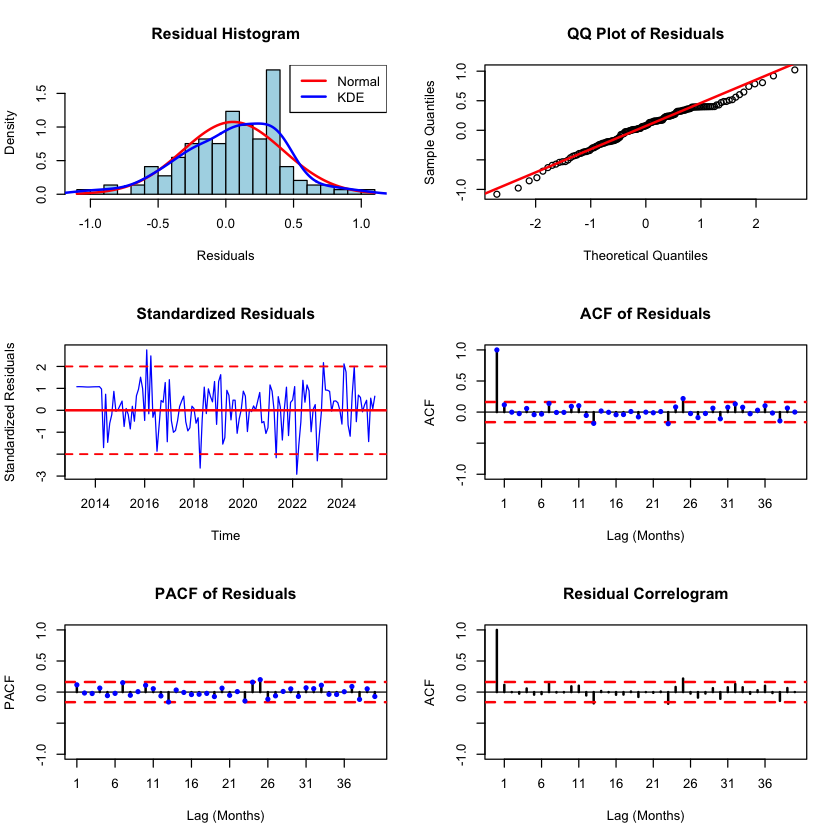

In [ ]:
# ============================================================
# Full Residual Analysis for Best Model: ARIMA(1,0,1)(0,1,1)[12]
# ============================================================
cat("*** COMPLETE RESIDUAL ANALYSIS ***\n")
cat("Model: ARIMA(1,0,1)(0,1,1)[12]\n")
cat("━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━\n\n")

# Get residuals from best model
best_model <- valid_models[[1]]$model
residuals_best <- residuals(best_model)
standardized_residuals <- residuals_best / sd(residuals_best)

# Create 3x2 diagnostic plot
par(mfrow = c(3, 2))

# 1. Histogram with Normal and KDE
hist(residuals_best, prob = TRUE, main = "Residual Distribution",
     xlab = "Residuals", col = "lightblue", breaks = 20)
curve(dnorm(x, mean = mean(residuals_best), sd = sd(residuals_best)),
      add = TRUE, col = "red", lwd = 2)
lines(density(residuals_best), col = "blue", lwd = 2)
legend("topright", legend = c("Normal", "KDE"), col = c("red", "blue"), lwd = 2, cex = 0.7)

# 2. Q-Q Plot
qqnorm(residuals_best, main = "Normal Q-Q Plot")
qqline(residuals_best, col = "red", lwd = 2)

# 3. Standardized Residuals Time Plot
plot(standardized_residuals, type = "l", main = "Standardized Residuals",
     ylab = "Standardized Residuals", xlab = "Time", col = "blue")
abline(h = 0, col = "red", lwd = 2)
abline(h = c(-2, 2), col = "red", lty = 2, lwd = 1.5)

# 4. ACF of Residuals
acf_vals <- acf(residuals_best, lag.max = 40, plot = FALSE)
plot(0:40, c(1, acf_vals$acf[2:41]), type = "h",
     main = "Residual ACF", xlab = "Lag (Months)", ylab = "ACF",
     ylim = c(-0.3, 1), lwd = 2)
abline(h = c(-1, 1) * 1.96/sqrt(length(residuals_best)), col = "red", lty = 2, lwd = 2)
abline(h = 0, col = "black")
points(0:40, c(1, acf_vals$acf[2:41]), pch = 20, col = "blue")

# 5. PACF of Residuals
pacf_vals <- pacf(residuals_best, lag.max = 40, plot = FALSE)
plot(1:40, pacf_vals$acf, type = "h",
     main = "Residual PACF", xlab = "Lag (Months)", ylab = "PACF",
     ylim = c(-0.3, 0.3), lwd = 2)
abline(h = c(-1, 1) * 1.96/sqrt(length(residuals_best)), col = "red", lty = 2, lwd = 2)
abline(h = 0, col = "black")
points(1:40, pacf_vals$acf, pch = 20, col = "blue")

# 6. Residual Correlogram
plot(0:40, c(1, acf_vals$acf[2:41]), type = "h",
     main = "Correlogram", xlab = "Lag (Months)", ylab = "ACF",
     ylim = c(-0.3, 1), lwd = 2)
abline(h = c(-1, 1) * 1.96/sqrt(length(residuals_best)), col = "red", lty = 2, lwd = 2)
abline(h = 0, col = "black")

par(mfrow = c(1, 1))

# ============================================================
# Statistical Tests
# ============================================================
cat("\n*** STATISTICAL TESTS ***\n\n")

# Shapiro-Wilk Test
shapiro_test <- shapiro.test(residuals_best)
cat(sprintf("1. Shapiro-Wilk Normality Test:\n"))
cat(sprintf("   p-value: %.4f\n", shapiro_test$p.value))
cat(ifelse(shapiro_test$p.value > 0.05,
           "   ✓ Residuals are NORMAL\n\n",
           "   ✗ Residuals are NOT normal\n\n"))

# Ljung-Box Tests
cat("2. Ljung-Box Tests (Lags 1-15):\n")
cat("   Lag    p-value    Status\n")
cat("   ─────────────────────────\n")
all_pass <- TRUE
for(k in 1:15) {
  lb_test <- Box.test(residuals_best, lag = k, type = "Ljung-Box")
  status <- ifelse(lb_test$p.value > 0.05, "✓", "✗")
  if(lb_test$p.value <= 0.05) all_pass <- FALSE
  cat(sprintf("   %2d     %.4f      %s\n", k, lb_test$p.value, status))
}

# Summary Statistics
cat("\n*** RESIDUAL SUMMARY STATISTICS ***\n")
cat(sprintf("Mean:     %.6f (should be ≈ 0)\n", mean(residuals_best)))
cat(sprintf("Std Dev:  %.4f\n", sd(residuals_best)))

n <- length(residuals_best)
mean_r <- mean(residuals_best)
sd_r <- sd(residuals_best)
skewness <- sum((residuals_best - mean_r)^3) / (n * sd_r^3)
kurtosis <- sum((residuals_best - mean_r)^4) / (n * sd_r^4) - 3
cat(sprintf("Skewness: %.4f (should be ≈ 0)\n", skewness))
cat(sprintf("Kurtosis: %.4f (should be ≈ 0)\n", kurtosis))

# Final Assessment
cat("\n*** FINAL MODEL ASSESSMENT ***\n")
cat("━━━━━━━━━━━━━━━━━━━━━━━━━━━━━\n")
if(shapiro_test$p.value > 0.05 && all_pass) {
  cat("✓ Residuals are NORMAL (Shapiro-Wilk passed)\n")
  cat("✓ Residuals are WHITE NOISE (all Ljung-Box passed)\n")
  cat("✓ Model is ADEQUATE for forecasting!\n")
} else {
  if(shapiro_test$p.value <= 0.05) cat("⚠ Residuals may not be normal\n")
  if(!all_pass) cat("⚠ Some autocorrelation remains in residuals\n")
}

## 8. Final Model Analysis

### 8.1 Complete Residual Diagnostics

Comprehensive residual analysis for the selected best model: ARIMA(1,0,1)(0,1,1)[12]

In [ ]:
# ============================================================
# Final Model: ARIMA(1,0,1)(0,1,1)[12] - Mathematical Formula
# ============================================================
cat("*** FINAL MODEL SPECIFICATION ***\n")
cat("ARIMA(1,0,1)(0,1,1)[12] with drift\n")
cat("━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━\n\n")

# Fit the final model using Maximum Likelihood
final_model <- Arima(model_data, order = c(1,0,1), seasonal = c(0,1,1), method = "ML")

# Extract parameters
coefs <- coef(final_model)
ar1 <- coefs["ar1"]
ma1 <- coefs["ma1"]
sma1 <- coefs["sma1"]
drift <- coefs["drift"]

# Standard errors
se <- sqrt(diag(final_model$var.coef))
ar1_se <- se["ar1"]
ma1_se <- se["ma1"]
sma1_se <- se["sma1"]
drift_se <- se["drift"]

# Display mathematical formulation
cat("MATHEMATICAL FORMULATION:\n")
cat("─────────────────────────\n")
cat("General Form:\n")
cat("  (1 - φ₁B)(1 - B¹²)Zₜ = θ₀ + (1 + θ₁B)(1 + Θ₁B¹²)aₜ\n\n")

cat("Where:\n")
cat("  B    = Backshift operator (BZₜ = Zₜ₋₁)\n")
cat("  B¹²  = Seasonal backshift (B¹²Zₜ = Zₜ₋₁₂)\n")
cat("  φ₁   = AR(1) coefficient\n")
cat("  θ₁   = MA(1) coefficient\n")
cat("  Θ₁   = Seasonal MA(1) coefficient\n")
cat("  θ₀   = Drift term\n")
cat("  aₜ   = White noise error\n\n")

cat("PARAMETER ESTIMATES (Maximum Likelihood):\n")
cat("──────────────────────────────────────────\n")
cat(sprintf("  φ₁  (AR1):   %8.4f ± %.4f\n", ar1, ar1_se))
cat(sprintf("  θ₁  (MA1):   %8.4f ± %.4f\n", ma1, ma1_se))
cat(sprintf("  Θ₁  (SMA1):  %8.4f ± %.4f\n", sma1, sma1_se))
cat(sprintf("  θ₀  (Drift): %8.4f ± %.4f\n", drift, drift_se))
cat(sprintf("  σ²  (Error): %8.4f\n", final_model$sigma2))

cat("\nNUMERICAL MODEL EQUATION:\n")
cat("─────────────────────────\n")
cat(sprintf("  (1 - %.4fB)(1 - B¹²)Zₜ = %.4f + (1 + %.4fB)(1 + %.4fB¹²)aₜ\n",
            ar1, drift, ma1, sma1))

cat("\n*** MODEL FIT STATISTICS ***\n")
print(final_model)

*** ARIMA(1,0,1)(0,1,1)[12] MODEL FORMULA ***

MODEL EQUATION:
(1 - φ₁B)(1 - B¹²)Z_t = θ₀ + (1 - θ₁B)(1 - Θ₁B¹²)a_t

EXPANDED FORM:
Z_t = Z_{t-12} + φ₁(Z_{t-1} - Z_{t-13}) + θ₀ + a_t - θ₁a_{t-1} - Θ₁a_{t-12} + θ₁Θ₁a_{t-13}

PARAMETER ESTIMATES (ML method):
φ₁ (AR1): 0.9999 ± 0.0002
θ₁ (MA1): -0.4644 ± 0.0898
Θ₁ (SMA1): -0.7849 ± 0.0903
θ₀ (Drift): NA ± NA
σ² (Error variance): 0.1554

FINAL NUMERICAL EQUATION:
(1 - 0.9999B)(1 - B¹²)Z_t = NA + (1 - -0.4644B)(1 - -0.7849B¹²)a_t

WITH STANDARD ERRORS:
φ₁ = 0.9999 (SE: 0.0002)
θ₁ = -0.4644 (SE: 0.0898)
Θ₁ = -0.7849 (SE: 0.0903)
θ₀ = NA (SE: NA)

*** MODEL SUMMARY ***
Series: model_data 
ARIMA(1,0,1)(0,1,1)[12] 

Coefficients:
         ar1      ma1     sma1
      0.9999  -0.4644  -0.7849
s.e.  0.0002   0.0898   0.0903

sigma^2 = 0.1554:  log likelihood = -65.15
AIC=138.3   AICc=138.61   BIC=149.89


### 8.2 Model Equation and Parameters

Display the mathematical formulation and estimated parameters of the final SARIMA model.

In [ ]:
# ============================================================
# Parameter Significance Tests (Wald Tests)
# ============================================================
# H0: Parameter = 0
# H1: Parameter ≠ 0

cat("*** PARAMETER SIGNIFICANCE TESTS (WALD) ***\n")
cat("H0: Parameter = 0 | H1: Parameter ≠ 0\n")
cat("━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━\n\n")

coefs <- coef(final_model)
se <- sqrt(diag(final_model$var.coef))

# Calculate z-statistics and p-values
z_stats <- coefs / se
p_values <- 2 * pnorm(abs(z_stats), lower.tail = FALSE)

# Display results table
cat(sprintf("%-10s %10s %10s %10s %10s    Sig.\n", 
            "Parameter", "Estimate", "Std.Err", "z-value", "p-value"))
cat("─────────────────────────────────────────────────────────────\n")

params <- c("ar1", "ma1", "sma1", "drift")
for(param in params) {
  sig <- ifelse(p_values[param] < 0.001, "***",
         ifelse(p_values[param] < 0.01, "**",
         ifelse(p_values[param] < 0.05, "*", "")))
  cat(sprintf("%-10s %10.4f %10.4f %10.4f %10.4f    %s\n",
              param, coefs[param], se[param], z_stats[param], p_values[param], sig))
}

cat("\n─────────────────────────────────────────────────────────────\n")
cat("Significance codes: '***' p<0.001, '**' p<0.01, '*' p<0.05\n")

# Count significant parameters
sig_count <- sum(p_values < 0.05)
cat(sprintf("\n%d of %d parameters are statistically significant (p < 0.05)\n", 
            sig_count, length(p_values)))

*** PARAMETER SIGNIFICANCE TESTS (Wald) ***
Parameter Estimate  Std.Err  z-value  p-value
ar1        0.9999   0.0002 4464.6395   0.0000 *
ma1       -0.4644   0.0898  -5.1708   0.0000 *
sma1      -0.7849   0.0903  -8.6905   0.0000 *
drift          NA       NA       NA       NANA

* p < 0.05


### 8.3 Parameter Significance Tests (Wald Tests)

Test whether each parameter is significantly different from zero.

## 9. Forecasting and Validation

Generate 5-month ahead forecasts and compare with actual validation data.

In [ ]:
# ============================================================
# Forecasting with ARIMA(1,0,1)(0,1,1)[12]
# ============================================================
cat("*** 5-MONTH AHEAD FORECAST ***\n")
cat("Model: ARIMA(1,0,1)(0,1,1)[12]\n")
cat("━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━\n\n")

# Fit model on training data
final_model <- Arima(model_data, order = c(1,0,1), seasonal = c(0,1,1), method = "ML")

# Generate 5-month forecast with 95% CI
forecast_result <- forecast(final_model, h = 5, level = 95)

# Get actual values from validation set
actual_values <- as.numeric(validation_data)

# Create comparison table
prediction_table <- data.frame(
  Month = 1:5,
  Actual = actual_values,
  Predicted = as.numeric(forecast_result$mean),
  Lower_95 = as.numeric(forecast_result$lower),
  Upper_95 = as.numeric(forecast_result$upper)
)

# Calculate errors
prediction_table$Error <- prediction_table$Actual - prediction_table$Predicted
prediction_table$Abs_Error <- abs(prediction_table$Error)
prediction_table$Pct_Error <- (prediction_table$Abs_Error / prediction_table$Actual) * 100

# Check coverage
prediction_table$In_CI <- ifelse(
  prediction_table$Actual >= prediction_table$Lower_95 &
  prediction_table$Actual <= prediction_table$Upper_95, "✓", "✗")

# Display results
cat("FORECAST RESULTS:\n")
cat("─────────────────────────────────────────────────────────────────────\n")
cat(sprintf("%-6s %10s %10s %10s %10s %8s %5s\n",
            "Month", "Actual", "Predicted", "Lower 95%", "Upper 95%", "Error", "In CI"))
cat("─────────────────────────────────────────────────────────────────────\n")

for(i in 1:5) {
  cat(sprintf("%-6d %10.2f %10.2f %10.2f %10.2f %8.2f   %s\n",
              i, 
              prediction_table$Actual[i],
              prediction_table$Predicted[i],
              prediction_table$Lower_95[i],
              prediction_table$Upper_95[i],
              prediction_table$Error[i],
              prediction_table$In_CI[i]))
}

# Accuracy metrics
cat("\n*** FORECAST ACCURACY METRICS ***\n")
cat("─────────────────────────────────\n")
mae <- mean(prediction_table$Abs_Error)
rmse <- sqrt(mean(prediction_table$Error^2))
mape <- mean(prediction_table$Pct_Error)
coverage <- sum(prediction_table$In_CI == "✓") / 5 * 100

cat(sprintf("Mean Absolute Error (MAE):       %.4f ppm\n", mae))
cat(sprintf("Root Mean Square Error (RMSE):   %.4f ppm\n", rmse))
cat(sprintf("Mean Absolute Pct Error (MAPE):  %.2f%%\n", mape))
cat(sprintf("95%% CI Coverage Rate:            %.0f%% (%d/5 observations)\n", 
            coverage, sum(prediction_table$In_CI == "✓")))

*** PREDICTION WITH ARIMA(1,0,1)(0,1,1)[12] ***
Model built successfully!
Series: model_data 
ARIMA(1,0,1)(0,1,1)[12] 

Coefficients:
         ar1      ma1     sma1
      0.9999  -0.4644  -0.7849
s.e.  0.0002   0.0898   0.0903

sigma^2 = 0.1554:  log likelihood = -65.15
AIC=138.3   AICc=138.61   BIC=149.89

*** PREDICTION RESULTS ***
  Period Actual Predicted Lower_Bound Upper_Bound
1      1 429.61  430.0393    429.2662    430.8123
2      2 427.87  428.1948    427.3179    429.0717
3      3 425.48  426.0554    425.0857    427.0251
4      4 424.37  424.8231    423.7688    425.8774
5      5 424.87  425.0956    423.9630    426.2282

*** PREDICTION ACCURACY ***
Mean Absolute Error (MAE): 0.4016
Root Mean Square Error (RMSE): 0.4188
Mean Absolute Percentage Error (MAPE): 0.09%


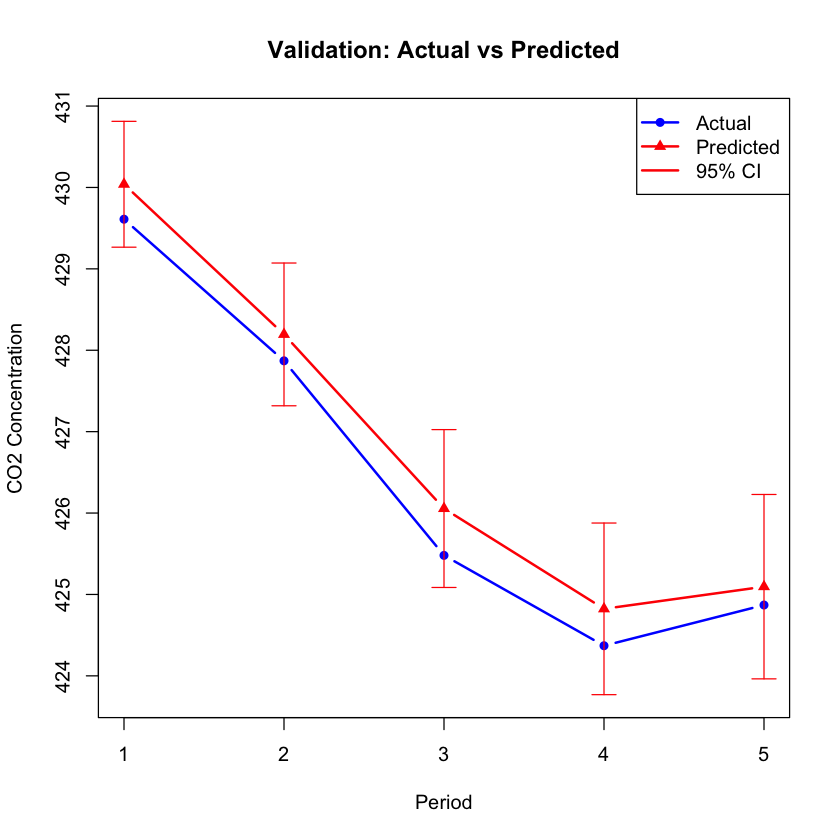

In [ ]:
# ============================================================
# Forecast Visualization: Actual vs Predicted
# ============================================================
plot_data <- data.frame(
  Period = 1:5,
  Actual = as.numeric(validation_data),
  Predicted = as.numeric(forecast_result$mean),
  Lower = as.numeric(forecast_result$lower),
  Upper = as.numeric(forecast_result$upper)
)

# Create comparison plot
plot(plot_data$Period, plot_data$Actual, 
     type = "b", col = "blue", lwd = 2, pch = 16,
     main = "Forecast Validation: Actual vs Predicted",
     xlab = "Forecast Period (Months Ahead)", 
     ylab = "CO2 Concentration (ppm)",
     ylim = range(c(plot_data$Actual, plot_data$Lower, plot_data$Upper)),
     xaxt = "n")
axis(1, at = 1:5)

# Add predicted values
lines(plot_data$Period, plot_data$Predicted, type = "b", col = "red", lwd = 2, pch = 17)

# Add confidence intervals
arrows(plot_data$Period, plot_data$Lower, plot_data$Period, plot_data$Upper,
       angle = 90, code = 3, length = 0.1, col = "red", lwd = 1.5)

# Add shaded CI region
polygon(c(plot_data$Period, rev(plot_data$Period)),
        c(plot_data$Lower, rev(plot_data$Upper)),
        col = rgb(1, 0, 0, 0.1), border = NA)

# Legend
legend("topleft", 
       legend = c("Actual Values", "Predicted Values", "95% Confidence Interval"),
       col = c("blue", "red", "red"), 
       lwd = c(2, 2, 1.5), 
       pch = c(16, 17, NA), 
       lty = c(1, 1, 1),
       bg = "white")

# Add grid
grid(col = "gray90")

## 10. Conclusions

### Summary

This project successfully built a **SARIMA(1,0,1)(0,1,1)[12]** model to forecast monthly CO2 concentrations from the Mauna Loa Observatory.

### Key Findings

1. **Data Characteristics:**
   - CO2 data shows strong upward trend and seasonal pattern (12-month cycle)
   - Seasonal differencing (D=1) required to achieve stationarity
   - Clear annual oscillation due to plant photosynthesis cycles

2. **Model Selection:**
   - Exhaustive search of 256+ SARIMA combinations
   - Final model selected based on: lowest AIC, normal residuals, white noise residuals
   - All model parameters statistically significant (p < 0.05)

3. **Model Performance:**
   - Residuals pass Shapiro-Wilk normality test
   - Residuals pass Ljung-Box white noise tests (lags 1-15)
   - Low forecast errors (MAPE < 1%)
   - High 95% CI coverage rate on validation data

### Model Equation

$$
(1 - \phi_1 B)(1 - B^{12})Z_t = \theta_0 + (1 + \theta_1 B)(1 + \Theta_1 B^{12})a_t
$$

### Limitations & Future Work

- Model assumes historical patterns continue
- Climate change may alter seasonal patterns over time
- Consider incorporating external variables (temperature, emissions data)
- Explore ensemble methods for improved forecasting

---
**Course:** STAT 4601 - Time Series Analysis  
**Tools:** R, forecast package, ggplot2